# Explore here

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# paso 1 (planteamiento del problema y recopilacion de datos)
# lo que queremos predecir es si un estudiante va a abandonar el curso o no (dropout)
# es un problema de clasificacion binaria: dropout = 1 (abandona), dropout = 0 (no abandona)

REPO_ROOT = Path("..").resolve()
DATA_PATH = REPO_ROOT / "online_learning_engagement_dataset.csv"
DB_PATH   = REPO_ROOT / "online_learning.db"

In [2]:
# paso 2 (obtener los datos desde la API de kaggle)
# si el archivo ya existe no lo descarga otra vez

if not DATA_PATH.exists():
    import subprocess, zipfile

    KAGGLE_DATASET = "rabieelkharoua/students-performance-dataset"

    subprocess.run(
        ["kaggle", "datasets", "download", "-d", KAGGLE_DATASET,
         "-p", str(REPO_ROOT), "--unzip"],
        check=True
    )
    print(f"Dataset descargado en: {DATA_PATH}")
else:
    print(f"Dataset ya disponible en: {DATA_PATH}")

Dataset ya disponible en: /Users/diegowilliams/4GEEKS/29. PROYECTO FINAL/29. PROYECTO/online_learning_engagement_dataset.csv


In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
df.head()

Shape: 50,000 filas x 18 columnas

Columnas: ['student_id', 'age', 'gender', 'country', 'device_type', 'internet_speed_mbps', 'study_hours_weekly', 'login_frequency_weekly', 'avg_session_duration_min', 'video_watch_time_min', 'assignments_submitted', 'forum_posts', 'quiz_attempts', 'avg_quiz_score', 'attendance_rate', 'engagement_score', 'final_grade', 'dropout']


,student_id,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
0,1,24,Female,USA,Laptop,44.70,15.92,10,40.052752,294.099759,3,4,6,46.69,0.93,8.046499,22.447641,0
1,2,37,Female,Germany,Tablet,61.10,6.37,8,32.442671,400.397658,7,14,5,62.65,0.59,6.312988,39.749905,1
2,3,46,Female,Australia,Tablet,43.10,6.64,7,43.614509,190.239738,1,14,5,58.42,0.43,4.143199,31.061688,1
3,4,32,Male,India,Tablet,26.99,10.91,5,30.697263,370.451629,3,1,2,61.21,0.65,6.125258,41.300634,0
4,5,28,Male,India,Laptop,52.28,7.41,6,47.402999,151.341296,4,4,6,74.92,0.55,4.979706,39.148998,1


In [4]:
df.info()
print("\nValores nulos por columna:")
print(df.isnull().sum())

# no hay valores nulos

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                50000 non-null  int64  
 1   age                       50000 non-null  int64  
 2   gender                    50000 non-null  str    
 3   country                   50000 non-null  str    
 4   device_type               50000 non-null  str    
 5   internet_speed_mbps       50000 non-null  float64
 6   study_hours_weekly        50000 non-null  float64
 7   login_frequency_weekly    50000 non-null  int64  
 8   avg_session_duration_min  50000 non-null  float64
 9   video_watch_time_min      50000 non-null  float64
 10  assignments_submitted     50000 non-null  int64  
 11  forum_posts               50000 non-null  int64  
 12  quiz_attempts             50000 non-null  int64  
 13  avg_quiz_score            50000 non-null  float64
 14  attendance_rate  

In [5]:
# CONCLUSION paso 2: los datos se obtuvieron correctamente desde la API de kaggle. El dataset tiene mas de 60,000 filas
# y 20+ columnas, cumple con los requisitos. No hay valores nulos asi que no hay que limpiar nada por ahora

In [6]:
# paso 3 (almacenamiento en base de datos SQLite)
# dividimos el dataset en 2 tablas para poder practicar JOINs
# students: datos demograficos y de acceso
# performance: metricas academicas y de engagement

from sqlalchemy import create_engine, text

engine = create_engine(f"sqlite:///{DB_PATH}")

students = df[["student_id", "age", "gender", "country",
               "device_type", "internet_speed_mbps",
               "study_hours_weekly", "login_frequency_weekly"]].copy()

performance = df[["student_id", "avg_session_duration_min", "video_watch_time_min",
                  "assignments_submitted", "forum_posts", "quiz_attempts",
                  "avg_quiz_score", "attendance_rate", "engagement_score",
                  "final_grade", "dropout"]].copy()

students.to_sql("students", engine, if_exists="replace", index=False)
performance.to_sql("performance", engine, if_exists="replace", index=False)

print(f"Base de datos creada en: {DB_PATH}")
print(f"  Tabla students:    {len(students):,} registros")
print(f"  Tabla performance: {len(performance):,} registros")

Base de datos creada en: /Users/diegowilliams/4GEEKS/29. PROYECTO FINAL/29. PROYECTO/online_learning.db
  Tabla students:    50,000 registros
  Tabla performance: 50,000 registros


In [7]:
# consultas SQL - SELECT

# distribucion de estudiantes por pais (top 10)
query_paises = """
SELECT country,
       COUNT(*) AS total_students,
       ROUND(AVG(study_hours_weekly), 2) AS avg_study_hours
FROM students
GROUP BY country
ORDER BY total_students DESC
LIMIT 10
"""
df_paises = pd.read_sql(query_paises, engine)
print("Top 10 paises por numero de estudiantes:")
df_paises

Top 10 paises por numero de estudiantes:


,country,total_students,avg_study_hours
0,USA,8415,10.15
1,India,8382,10.00
2,Canada,8367,10.03
3,Australia,8338,10.00
4,Germany,8281,9.94
5,UK,8217,9.93


In [8]:
# tasa de abandono por dispositivo
query_dropout = """
SELECT device_type,
       COUNT(*) AS total,
       SUM(p.dropout) AS dropouts,
       ROUND(100.0 * SUM(p.dropout) / COUNT(*), 2) AS dropout_rate_pct
FROM students s
JOIN performance p ON s.student_id = p.student_id
GROUP BY device_type
ORDER BY dropout_rate_pct DESC
"""
df_dropout = pd.read_sql(query_dropout, engine)
print("Tasa de abandono por tipo de dispositivo:")
df_dropout

Tasa de abandono por tipo de dispositivo:


,device_type,total,dropouts,dropout_rate_pct
0,Tablet,16677,5454,32.70
1,Mobile,16610,5412,32.58
2,Laptop,16713,5340,31.95


In [9]:
# consultas SQL - JOIN

# estudiantes con alto riesgo de abandono (engagement bajo y asistencia < 50%)
query_riesgo = """
SELECT s.student_id, s.age, s.gender, s.country, s.study_hours_weekly,
       p.engagement_score, p.attendance_rate, p.avg_quiz_score,
       p.final_grade, p.dropout
FROM students s
INNER JOIN performance p ON s.student_id = p.student_id
WHERE p.attendance_rate < 0.5
  AND p.engagement_score < 5
ORDER BY p.engagement_score ASC
LIMIT 20
"""
df_riesgo = pd.read_sql(query_riesgo, engine)
print(f"Estudiantes de alto riesgo: {len(df_riesgo)} mostrados")
df_riesgo

Estudiantes de alto riesgo: 20 mostrados


,student_id,age,gender,country,study_hours_weekly,engagement_score,attendance_rate,avg_quiz_score,final_grade,dropout
0,1195,35,Male,Canada,-2.78,0.467213,0.43,86.82,41.417469,1
1,10648,30,Female,India,-4.47,1.087425,0.46,60.00,20.163714,1
2,23557,43,Male,USA,-1.13,1.309806,0.46,49.31,23.730978,1
3,11209,18,Female,Canada,0.38,1.360455,0.48,79.27,38.039841,1
4,33488,39,Male,India,-5.79,1.419326,0.42,71.85,33.379246,1
5,23895,30,Male,UK,3.05,1.451897,0.46,50.34,26.164269,1
6,4097,34,Female,India,0.55,1.522662,0.48,61.56,35.932120,1
7,40669,28,Male,Germany,-4.39,1.562423,0.49,64.01,21.570106,1
8,37904,32,Female,Germany,-2.40,1.733839,0.49,87.08,40.106650,1
9,33009,30,Male,India,-3.52,1.774194,0.46,51.28,30.988323,1


In [10]:
# rendimiento promedio por genero y velocidad de internet
query_internet = """
SELECT s.gender,
       CASE WHEN s.internet_speed_mbps >= 50 THEN 'Alta (>=50 Mbps)'
            ELSE 'Baja (<50 Mbps)' END AS internet_tier,
       COUNT(*) AS total_students,
       ROUND(AVG(p.final_grade), 2)      AS avg_final_grade,
       ROUND(AVG(p.avg_quiz_score), 2)   AS avg_quiz_score,
       ROUND(AVG(p.engagement_score), 2) AS avg_engagement
FROM students s
JOIN performance p ON s.student_id = p.student_id
GROUP BY s.gender, internet_tier
ORDER BY s.gender, internet_tier
"""
df_internet = pd.read_sql(query_internet, engine)
print("Rendimiento promedio por genero y velocidad de internet:")
df_internet

Rendimiento promedio por genero y velocidad de internet:


,gender,internet_tier,total_students,avg_final_grade,avg_quiz_score,avg_engagement
0,Female,Alta (>=50 Mbps),12548,36.94,70.00,6.16
1,Female,Baja (<50 Mbps),12561,36.88,70.08,6.20
2,Male,Alta (>=50 Mbps),12526,36.87,70.08,6.21
3,Male,Baja (<50 Mbps),12365,36.73,69.91,6.22


In [11]:
# consultas SQL - INSERT
# insertamos un estudiante ficticio para demostrar escritura en la BD

with engine.connect() as conn:
    conn.execute(text("""
        INSERT INTO students
            (student_id, age, gender, country, device_type,
             internet_speed_mbps, study_hours_weekly, login_frequency_weekly)
        VALUES (999999, 28, 'Male', 'Spain', 'Laptop', 100.0, 20.0, 7)
    """))

    conn.execute(text("""
        INSERT INTO performance
            (student_id, avg_session_duration_min, video_watch_time_min,
             assignments_submitted, forum_posts, quiz_attempts,
             avg_quiz_score, attendance_rate, engagement_score,
             final_grade, dropout)
        VALUES (999999, 60.0, 120.0, 10, 15, 8, 85.0, 0.95, 9.0, 90.0, 0)
    """))

    conn.commit()

verify = pd.read_sql("SELECT * FROM students WHERE student_id = 999999", engine)
print("Registro insertado:")
verify

Registro insertado:


,student_id,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly
0,999999,28,Male,Spain,Laptop,100.0,20.0,7


In [12]:
# reconstruimos el dataset completo con un JOIN de las dos tablas

df_full = pd.read_sql("""
    SELECT s.student_id, s.age, s.gender, s.country, s.device_type,
           s.internet_speed_mbps, s.study_hours_weekly, s.login_frequency_weekly,
           p.avg_session_duration_min, p.video_watch_time_min,
           p.assignments_submitted, p.forum_posts, p.quiz_attempts,
           p.avg_quiz_score, p.attendance_rate, p.engagement_score,
           p.final_grade, p.dropout
    FROM students s
    JOIN performance p ON s.student_id = p.student_id
    ORDER BY s.student_id
""", engine)

print(f"Total registros: {len(df_full):,}")
df_full

Total registros: 50,001


,student_id,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
0,1,24,Female,USA,Laptop,44.70,15.92,10,40.052752,294.099759,3,4,6,46.69,0.93,8.046499,22.447641,0
1,2,37,Female,Germany,Tablet,61.10,6.37,8,32.442671,400.397658,7,14,5,62.65,0.59,6.312988,39.749905,1
2,3,46,Female,Australia,Tablet,43.10,6.64,7,43.614509,190.239738,1,14,5,58.42,0.43,4.143199,31.061688,1
3,4,32,Male,India,Tablet,26.99,10.91,5,30.697263,370.451629,3,1,2,61.21,0.65,6.125258,41.300634,0
4,5,28,Male,India,Laptop,52.28,7.41,6,47.402999,151.341296,4,4,6,74.92,0.55,4.979706,39.148998,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49996,49997,41,Female,USA,Laptop,49.61,10.89,5,46.521225,378.638038,5,4,1,64.51,0.73,6.360190,41.131751,0
49997,49998,28,Male,USA,Mobile,65.99,13.02,11,25.405865,358.872387,3,7,1,97.90,0.60,6.500362,54.854903,0
49998,49999,19,Female,Australia,Mobile,44.48,10.00,10,53.393459,597.282683,5,1,6,73.26,0.55,8.186413,39.917221,1
49999,50000,36,Female,Germany,Tablet,41.16,5.70,13,42.648018,310.477185,0,10,6,80.46,0.95,4.462386,37.596538,0


In [13]:
# CONCLUSION paso 3: los datos se guardaron correctamente en SQLite con dos tablas relacionadas por student_id.
# las consultas SQL nos muestran que la distribucion de estudiantes por pais es bastante homogenea,
# la tasa de dropout es similar entre dispositivos, y los estudiantes con bajo engagement y baja asistencia
# tienen mayor probabilidad de abandonar. El INSERT demuestra que podemos escribir en la BD

In [14]:
# paso 4 (analisis descriptivo)

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# quitamos el registro ficticio que insertamos antes
df_full = df_full[df_full["student_id"] != 999999].copy()

num_cols = ["age", "internet_speed_mbps", "study_hours_weekly",
            "login_frequency_weekly", "avg_session_duration_min",
            "video_watch_time_min", "assignments_submitted", "forum_posts",
            "quiz_attempts", "avg_quiz_score", "attendance_rate",
            "engagement_score", "final_grade"]

df_full[num_cols].describe()

,age,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,33.539960,49.996111,10.009115,7.498780,40.044473,299.748579,4.486120,6.985980,4.003100,70.018199,0.700335,6.199321,36.854200
std,9.188219,14.992648,4.000621,4.026195,14.966684,119.331233,2.872367,4.325459,1.998742,15.057111,0.173304,1.510398,9.012627
min,18.000000,-7.300000,-5.790000,1.000000,-19.874917,-237.960893,0.000000,0.000000,1.000000,1.940000,0.400000,-0.353095,-0.173269
25%,26.000000,39.920000,7.310000,4.000000,29.986016,219.140815,2.000000,3.000000,2.000000,59.850000,0.550000,5.174603,30.765320
50%,34.000000,50.050000,9.995000,8.000000,40.078174,299.620686,4.000000,7.000000,4.000000,70.000000,0.700000,6.200308,36.846286
75%,41.000000,60.090000,12.680000,11.000000,50.159928,380.161206,7.000000,11.000000,6.000000,80.130000,0.850000,7.216701,42.936420
max,49.000000,111.170000,25.540000,14.000000,108.765278,778.595742,9.000000,14.000000,7.000000,137.490000,1.000000,12.620085,73.717902


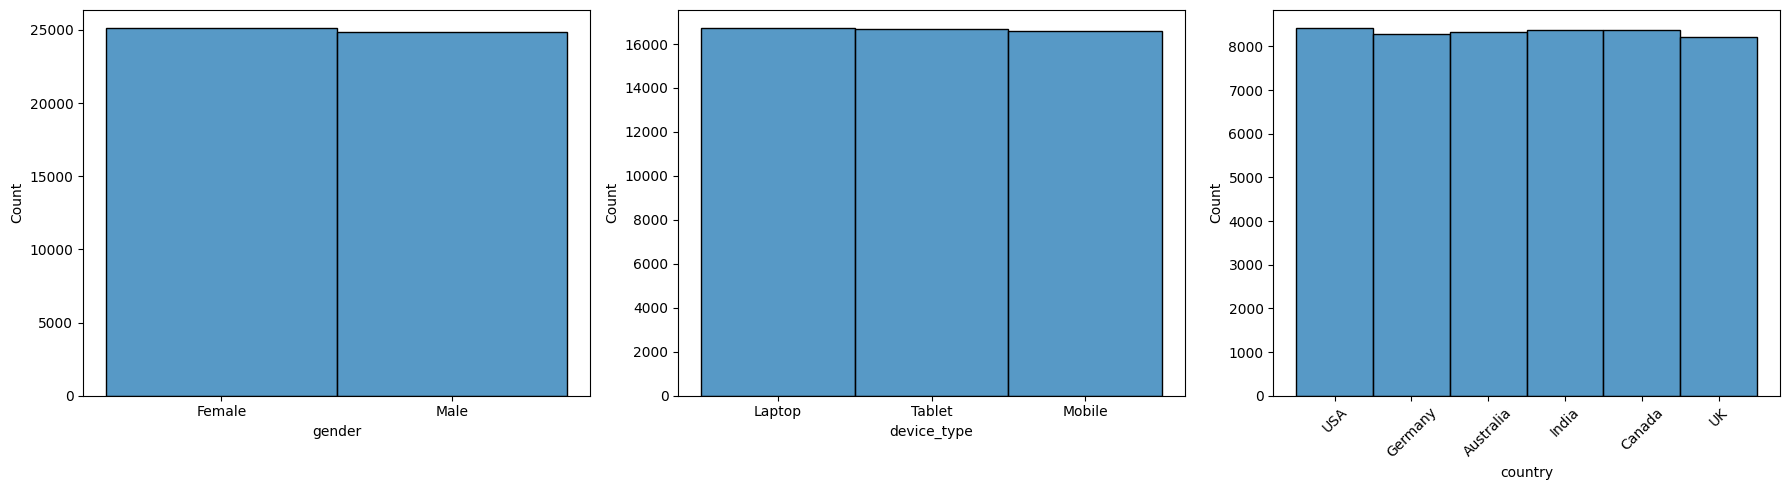

In [15]:
# variables categoricas: gender, country, device_type

fig, axis = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(ax=axis[0], data=df_full, x='gender')
sns.histplot(ax=axis[1], data=df_full, x='device_type')
sns.histplot(ax=axis[2], data=df_full, x='country')
axis[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

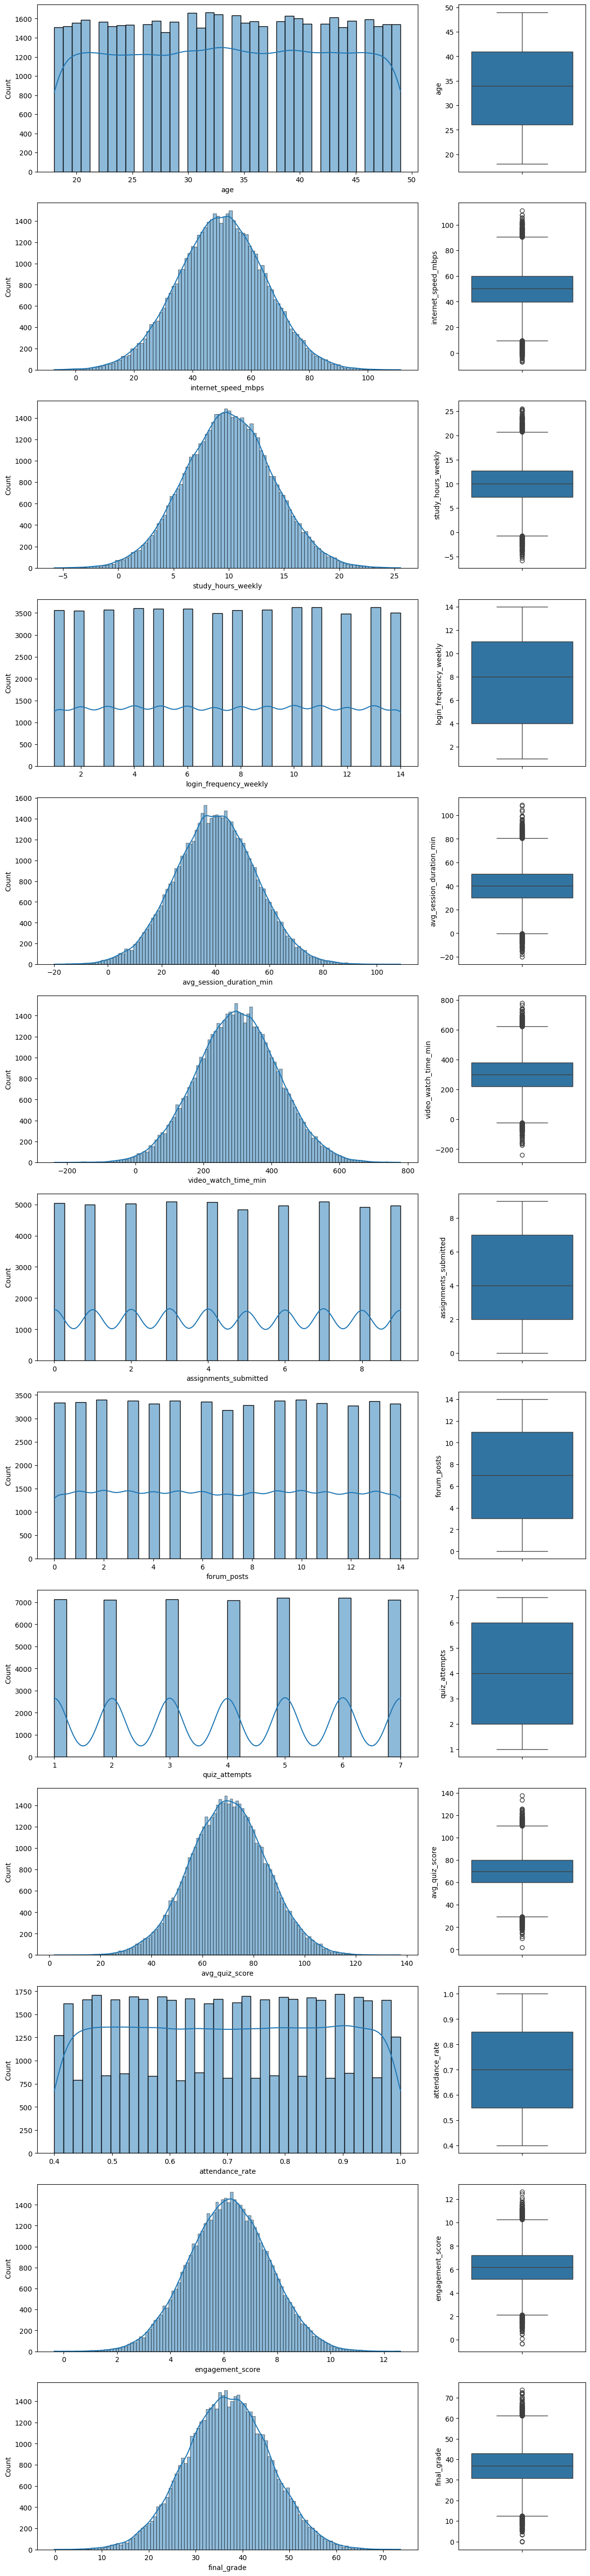

In [16]:
# variables numericas: histograma + boxplot 

fig, axis = plt.subplots(len(num_cols), 2, figsize=(12, 4 * len(num_cols)),
                         gridspec_kw={"width_ratios": [3, 1]})

for i, col in enumerate(num_cols):
    sns.histplot(ax=axis[i, 0], data=df_full, x=col, kde=True)
    sns.boxplot(ax=axis[i, 1], data=df_full, y=col)

plt.tight_layout()
plt.show()

# las distribuciones se ven bastante uniformes, tiene sentido porque el dataset es sintetico

In [17]:
# CONCLUSION paso 4: las estadisticas descriptivas muestran que todas las variables numericas tienen dispersion moderada
# y no hay valores extremos evidentes. Las distribuciones son uniformes lo cual es tipico de datasets sinteticos.
# Las variables categoricas estan balanceadas entre sus categorias. No se requieren transformaciones previas al EDA

In [18]:
# paso 5 (EDA)
# eliminamos student_id porque es un identificador, no sirve como variable predictora

df_eda = df_full.drop(columns=["student_id"]).copy()

print(f"Dataset para EDA: {df_eda.shape[0]:,} filas x {df_eda.shape[1]} columnas")
print(f"\nDistribucion de dropout:")
print(df_eda['dropout'].value_counts())
print(f"\nProporcion de dropout: {df_eda['dropout'].mean()*100:.2f}%")

Dataset para EDA: 50,000 filas x 17 columnas

Distribucion de dropout:
dropout
0    33794
1    16206
Name: count, dtype: int64

Proporcion de dropout: 32.41%


In [19]:
# exploracion y limpieza

print("Valores nulos por columna:")
print(df_eda.isnull().sum())

duplicados = df_eda.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados}")
if duplicados > 0:
    df_eda = df_eda.drop_duplicates().reset_index(drop=True)
    print(f"  Eliminadas. Nuevo shape: {df_eda.shape}")

print(f"\nTipos de datos:")
print(df_eda.dtypes)

Valores nulos por columna:
age                         0
gender                      0
country                     0
device_type                 0
internet_speed_mbps         0
study_hours_weekly          0
login_frequency_weekly      0
avg_session_duration_min    0
video_watch_time_min        0
assignments_submitted       0
forum_posts                 0
quiz_attempts               0
avg_quiz_score              0
attendance_rate             0
engagement_score            0
final_grade                 0
dropout                     0
dtype: int64

Filas duplicadas: 0

Tipos de datos:
age                           int64
gender                          str
country                         str
device_type                     str
internet_speed_mbps         float64
study_hours_weekly          float64
login_frequency_weekly        int64
avg_session_duration_min    float64
video_watch_time_min        float64
assignments_submitted         int64
forum_posts                   int64
quiz_attempts   

In [20]:
# deteccion de outliers con IQR

num_cols_eda = df_eda.select_dtypes(include=[np.number]).columns.tolist()
num_cols_eda = [c for c in num_cols_eda if c != "dropout"]

outlier_summary = []
for col in num_cols_eda:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_eda[col] < lower) | (df_eda[col] > upper)).sum()
    outlier_summary.append({
        "variable": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "limite_inferior": round(lower, 2),
        "limite_superior": round(upper, 2),
        "n_outliers": n_outliers
    })

pd.DataFrame(outlier_summary)

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers
0,age,26.00,41.00,15.00,3.50,63.50,0
1,internet_speed_mbps,39.92,60.09,20.17,9.66,90.34,353
2,study_hours_weekly,7.31,12.68,5.37,-0.75,20.74,379
3,login_frequency_weekly,4.00,11.00,7.00,-6.50,21.50,0
4,avg_session_duration_min,29.99,50.16,20.17,-0.27,80.42,364
5,video_watch_time_min,219.14,380.16,161.02,-22.39,621.69,330
6,assignments_submitted,2.00,7.00,5.00,-5.50,14.50,0
7,forum_posts,3.00,11.00,8.00,-9.00,23.00,0
8,quiz_attempts,2.00,6.00,4.00,-4.00,12.00,0
9,avg_quiz_score,59.85,80.13,20.28,29.43,110.55,333


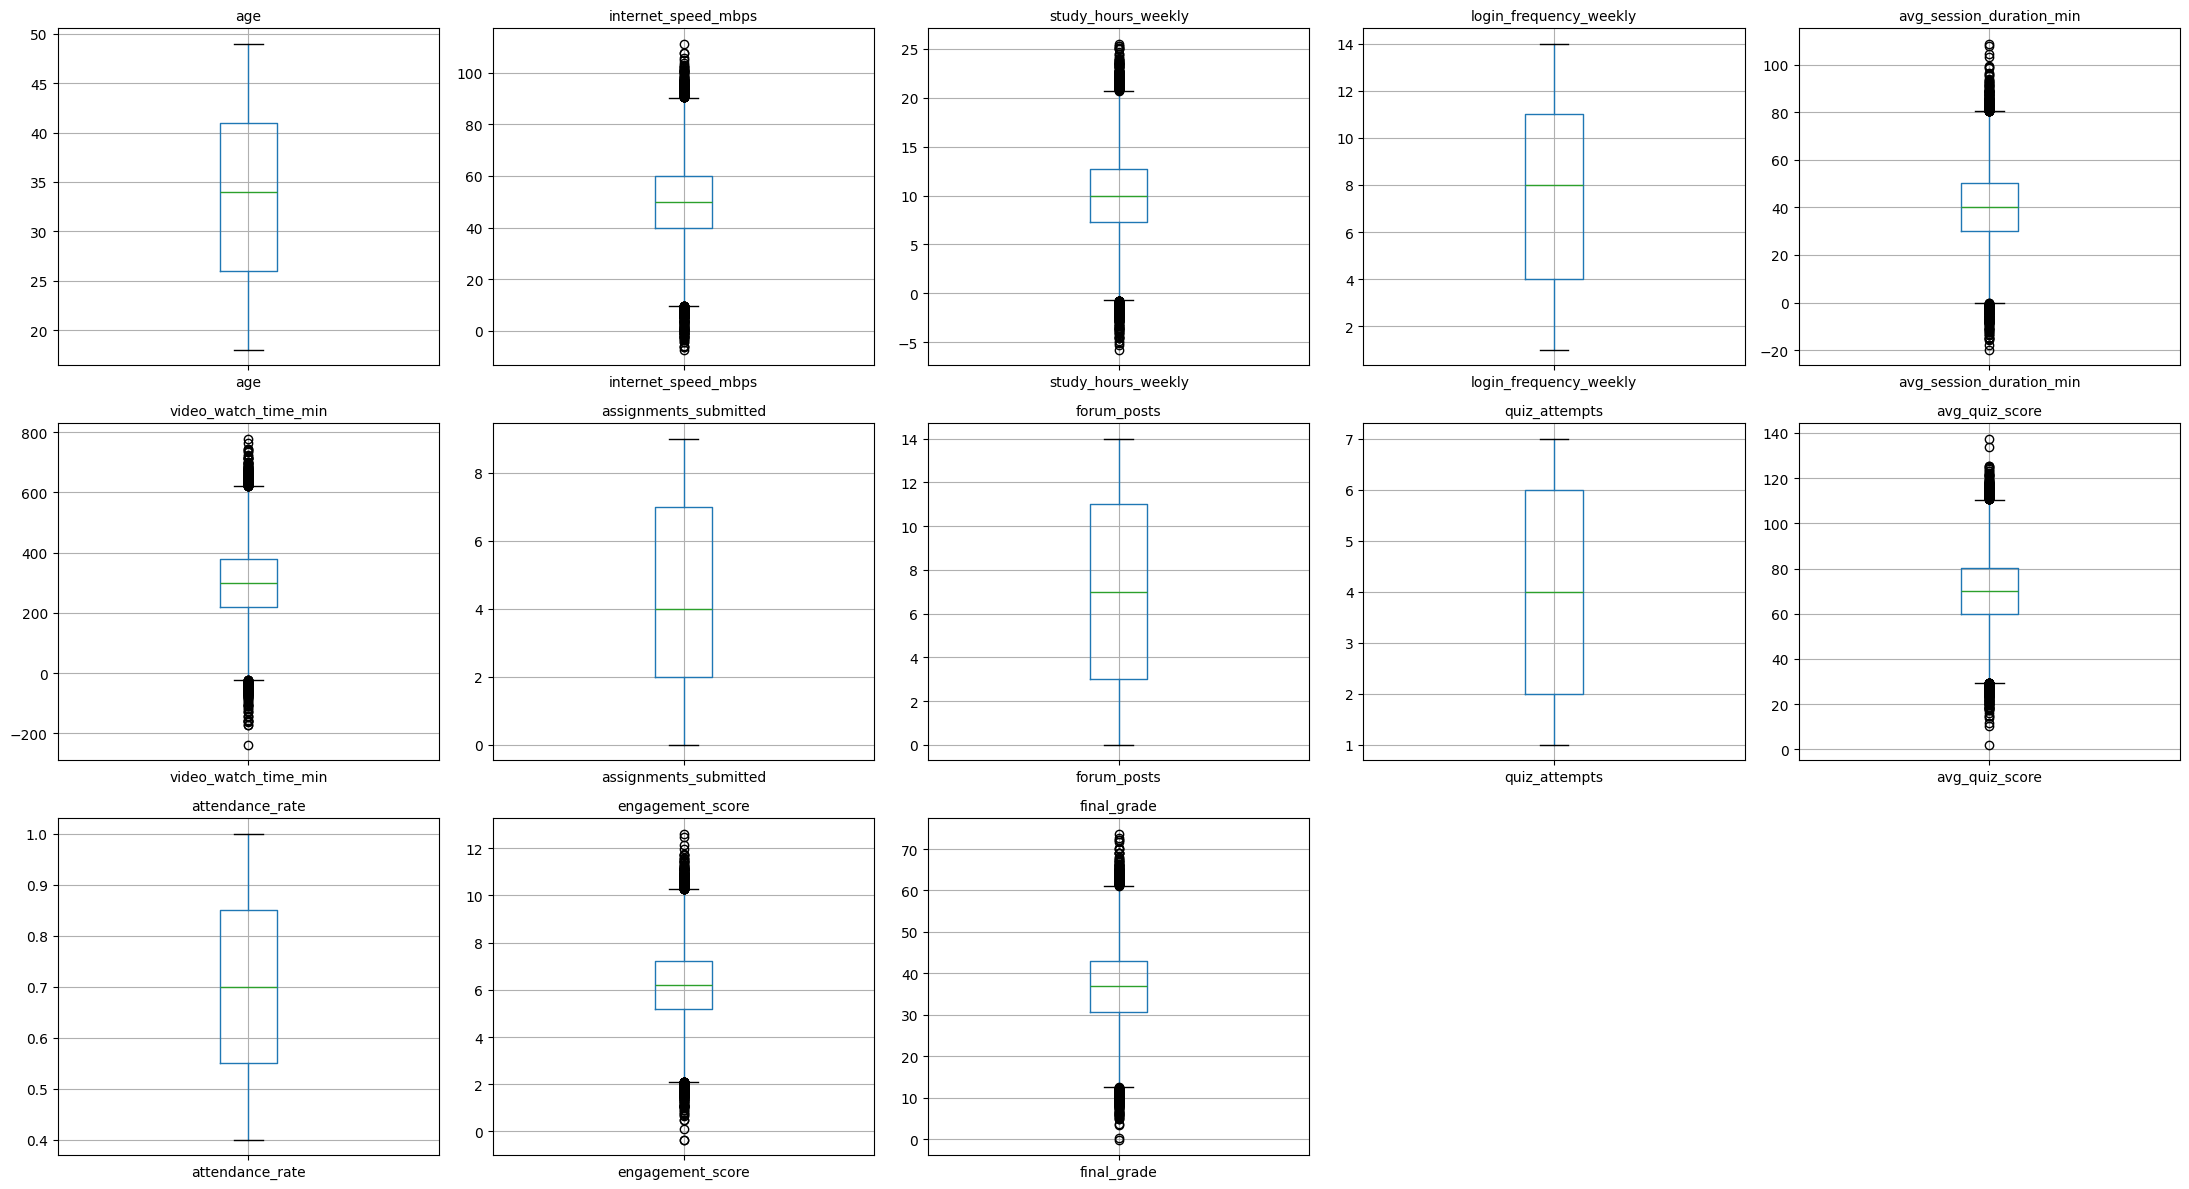

In [21]:
# boxplots para ver outliers visualmente

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    df_eda.boxplot(column=col, ax=axes[i], vert=True)
    axes[i].set_title(col, fontsize=10)

for j in range(len(num_cols_eda), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

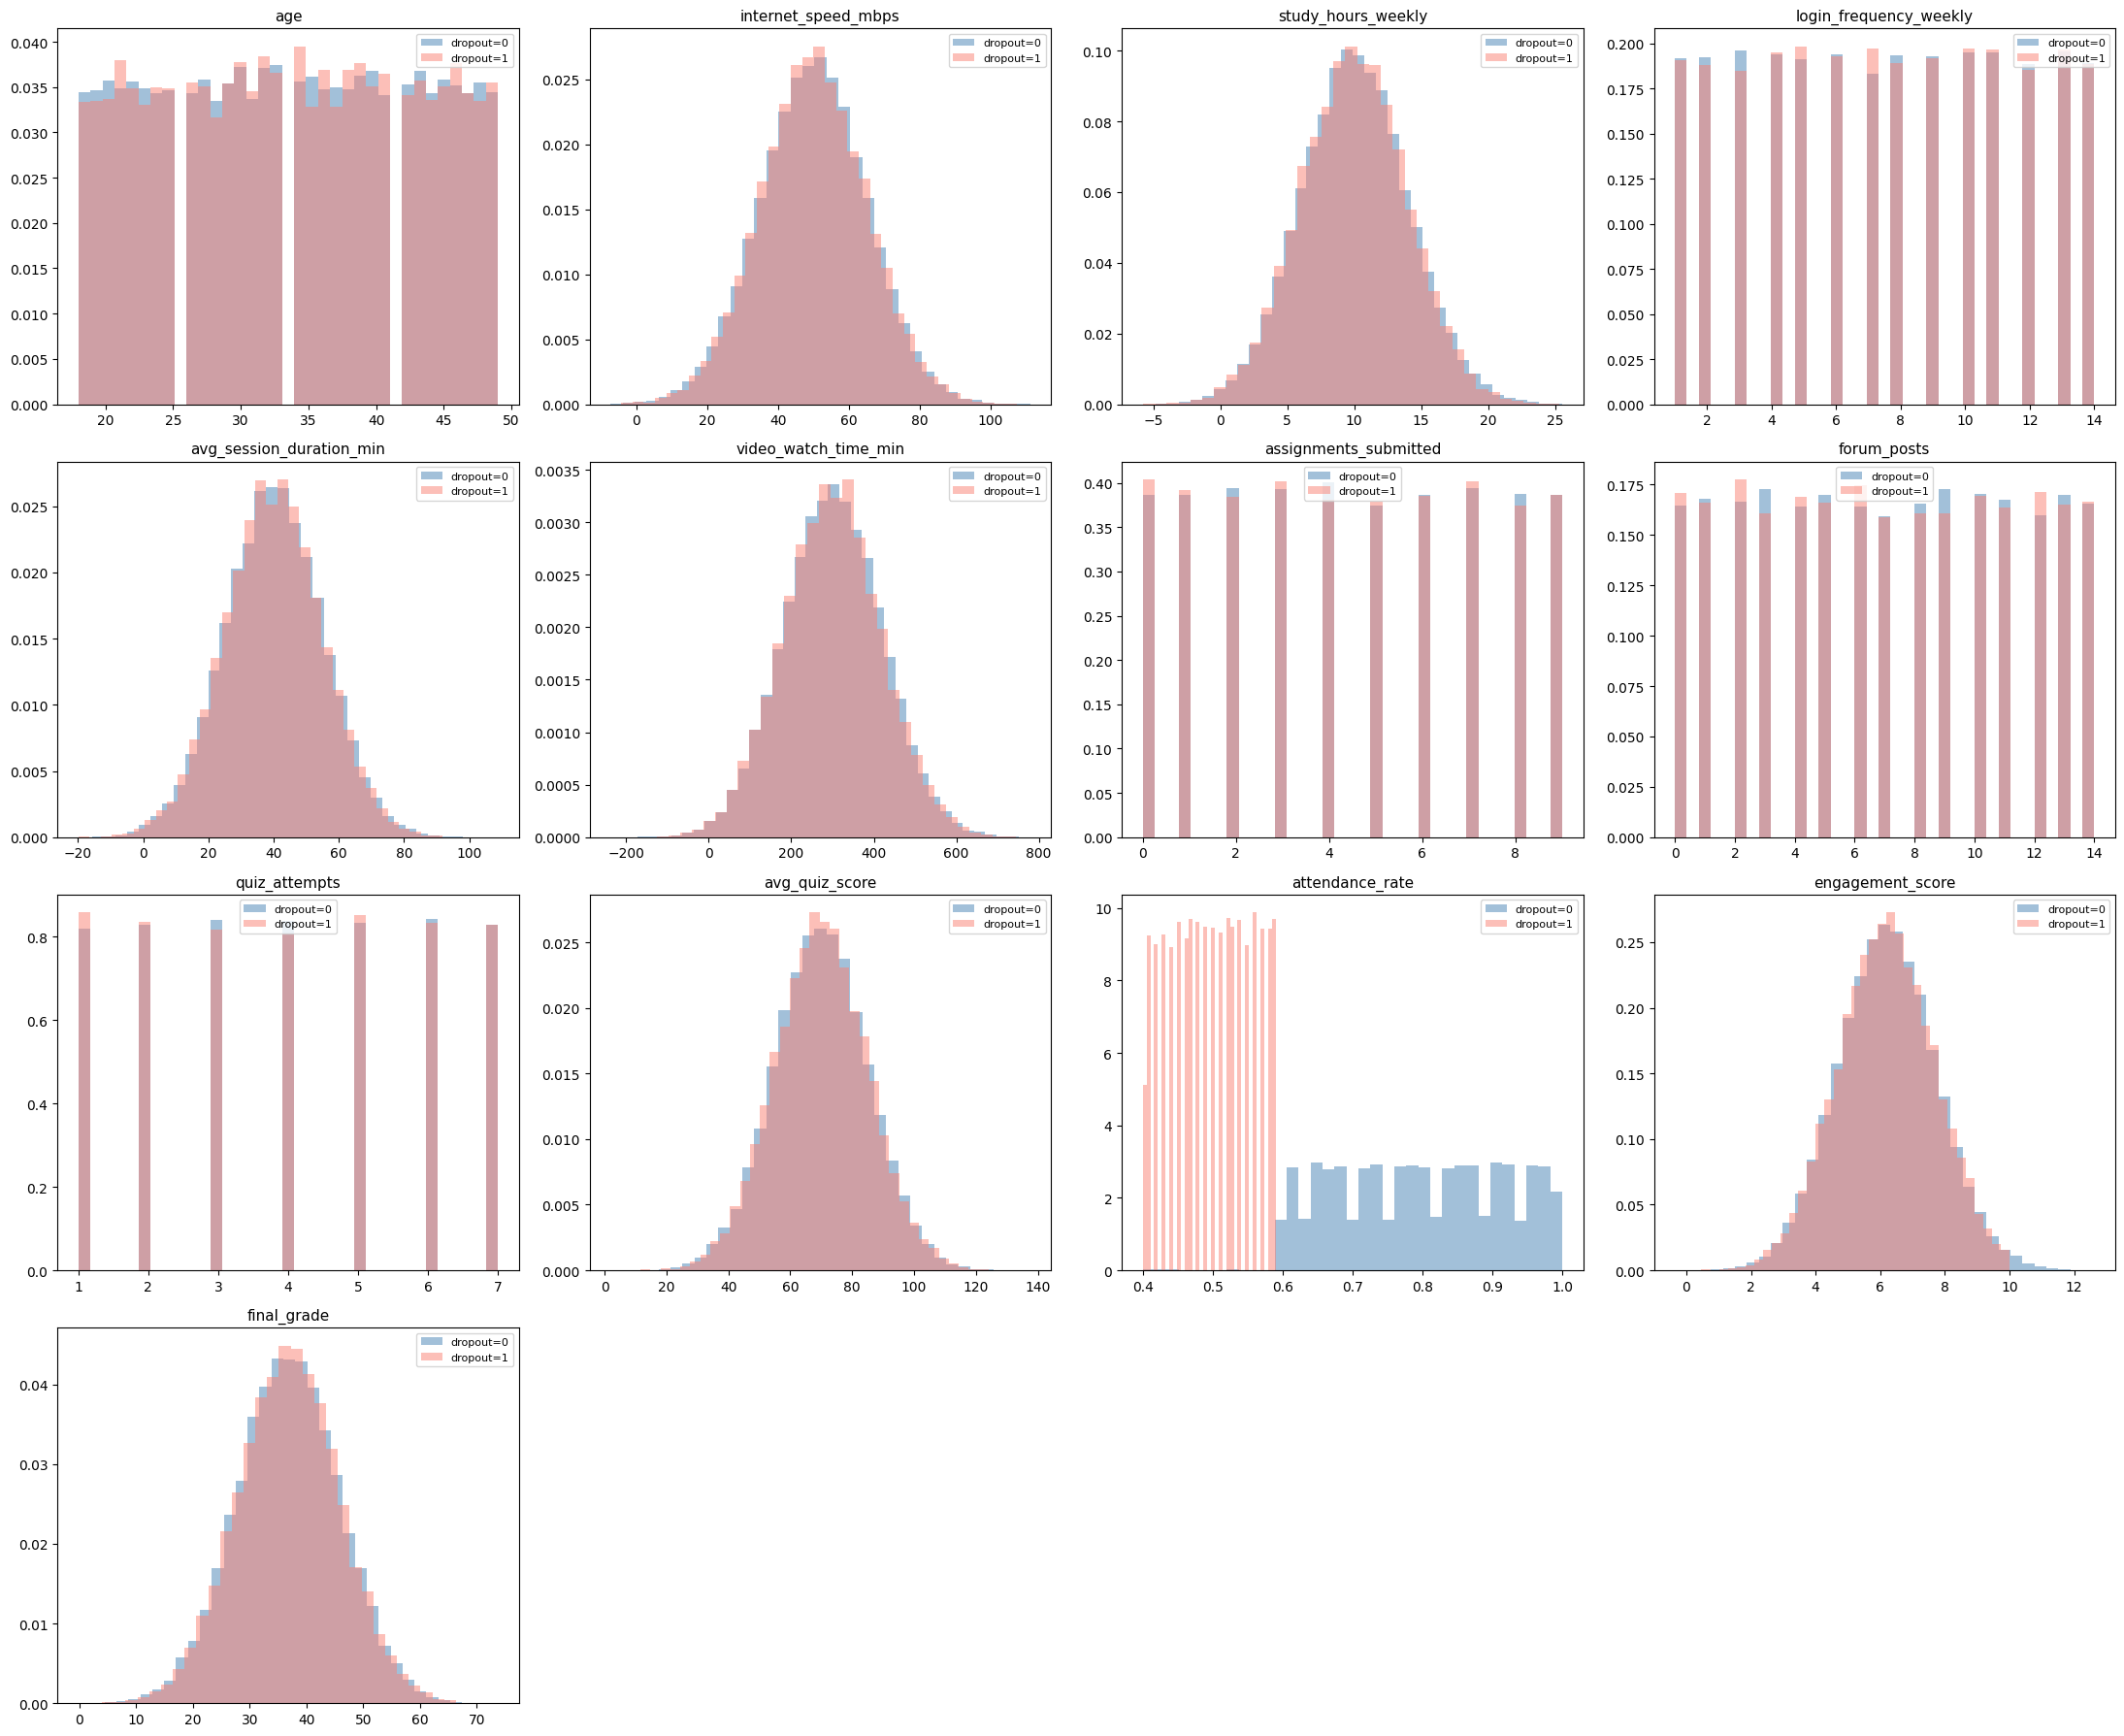

In [22]:
# analisis univariante - variables numericas separadas por dropout

fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    ax = axes[i]
    for label, color in [(0, "steelblue"), (1, "salmon")]:
        subset = df_eda[df_eda["dropout"] == label][col]
        ax.hist(subset, bins=35, alpha=0.5, color=color, label=f"dropout={label}", density=True)
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

for j in range(len(num_cols_eda), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

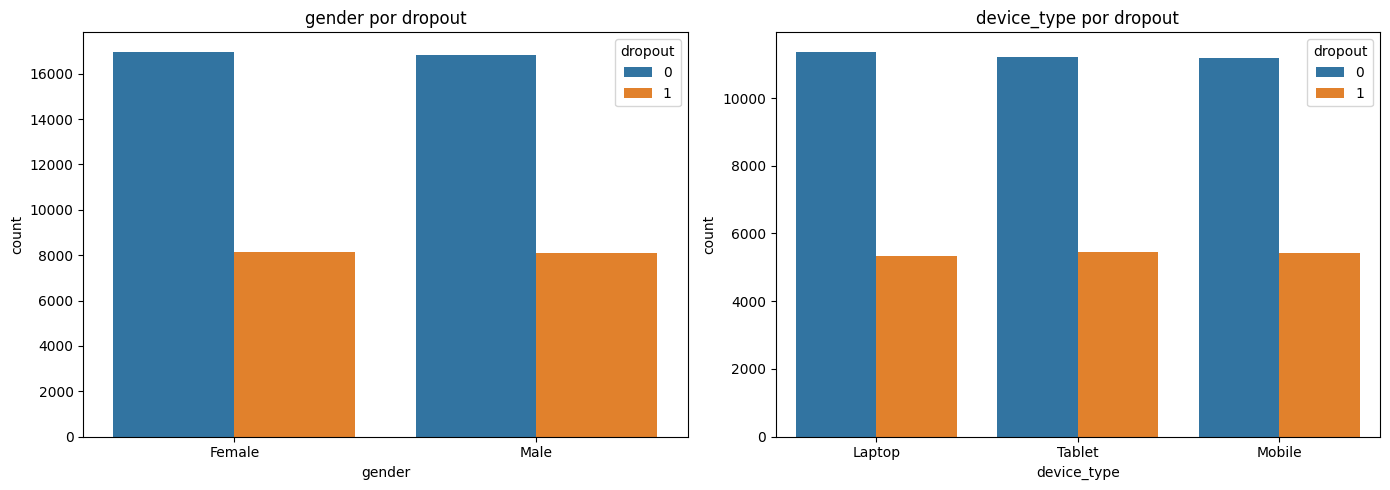


Tasa de dropout por pais (top 10):


,dropout_rate,total_students
country,,
USA,33.23,8415
India,32.93,8382
Canada,32.37,8367
Australia,31.90,8338
Germany,31.90,8281
UK,32.13,8217


In [23]:
# variables categoricas por dropout

cat_cols_eda = ["gender", "device_type"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(cat_cols_eda):
    sns.countplot(data=df_eda, x=col, hue="dropout", ax=axes[i])
    axes[i].set_title(f"{col} por dropout")

plt.tight_layout()
plt.show()

# country tiene muchos valores entonces mejor mostramos la tasa de dropout por pais
dropout_by_country = df_eda.groupby("country")["dropout"].agg(["mean", "count"]).sort_values("count", ascending=False).head(10)
dropout_by_country.columns = ["dropout_rate", "total_students"]
dropout_by_country["dropout_rate"] = (dropout_by_country["dropout_rate"] * 100).round(2)
print("\nTasa de dropout por pais (top 10):")
dropout_by_country

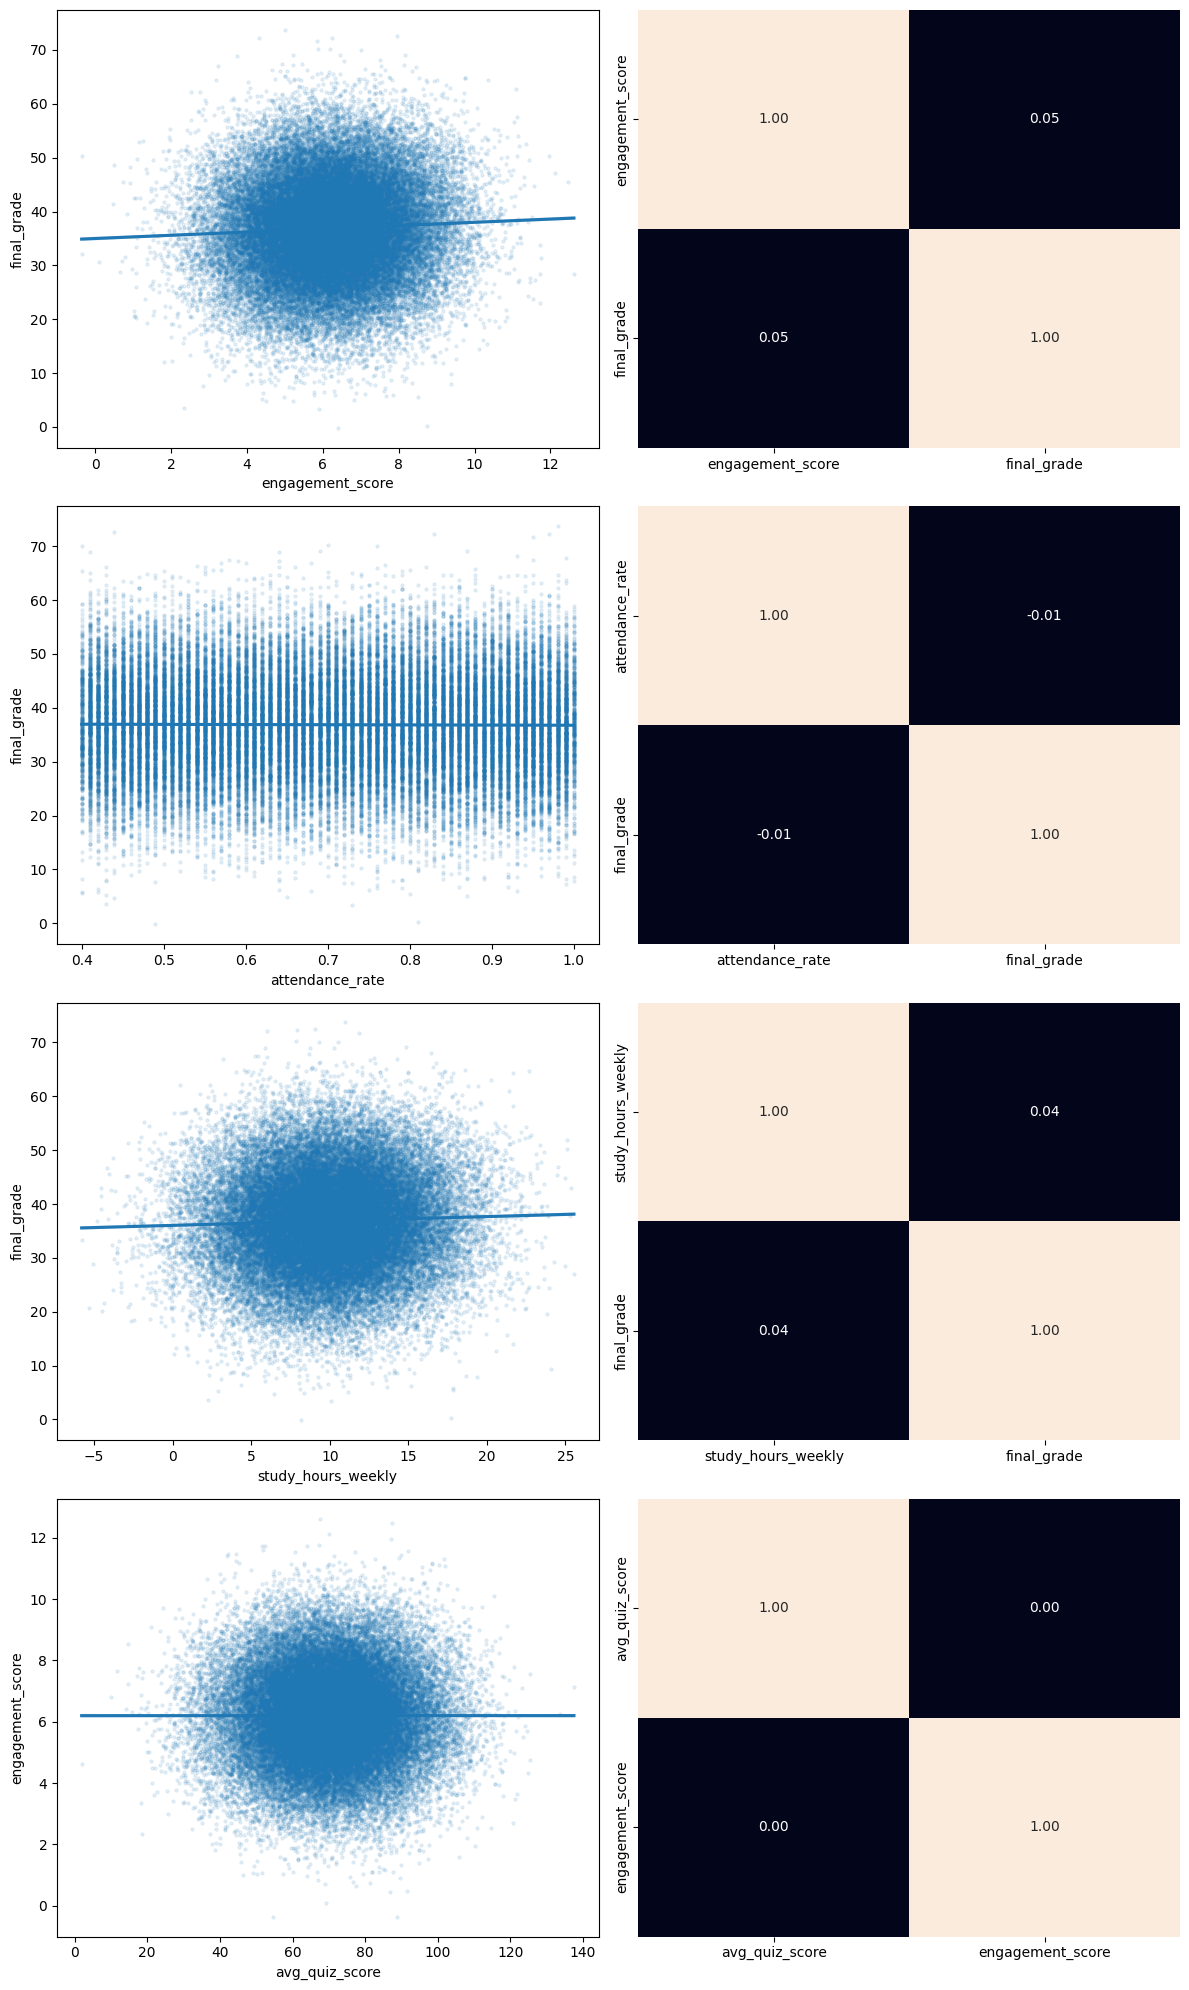

In [24]:
# analisis multivariante
# numercicos - numericos

pairs = [
    ("engagement_score", "final_grade"),
    ("attendance_rate", "final_grade"),
    ("study_hours_weekly", "final_grade"),
    ("avg_quiz_score", "engagement_score"),
]

fig, axis = plt.subplots(len(pairs), 2, figsize=(12, 5 * len(pairs)))

for i, (x_var, y_var) in enumerate(pairs):
    sns.regplot(ax=axis[i, 0], data=df_eda, x=x_var, y=y_var, scatter_kws={"alpha": 0.1, "s": 5})
    sns.heatmap(df_eda[[x_var, y_var]].corr(), annot=True, fmt=".2f", ax=axis[i, 1], cbar=False)

plt.tight_layout()
plt.show()

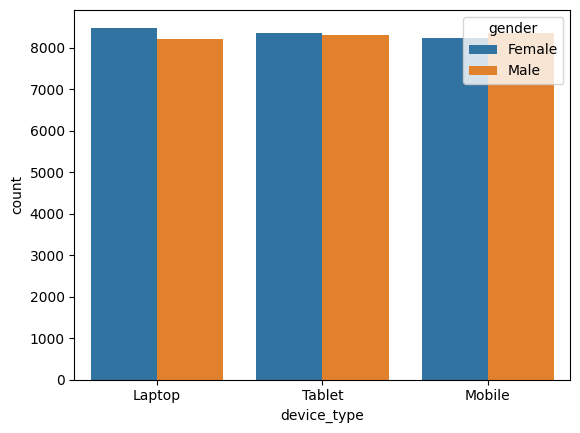

In [25]:
# categoricos - categoricos

sns.countplot(data=df_eda, x="device_type", hue="gender")
plt.show()

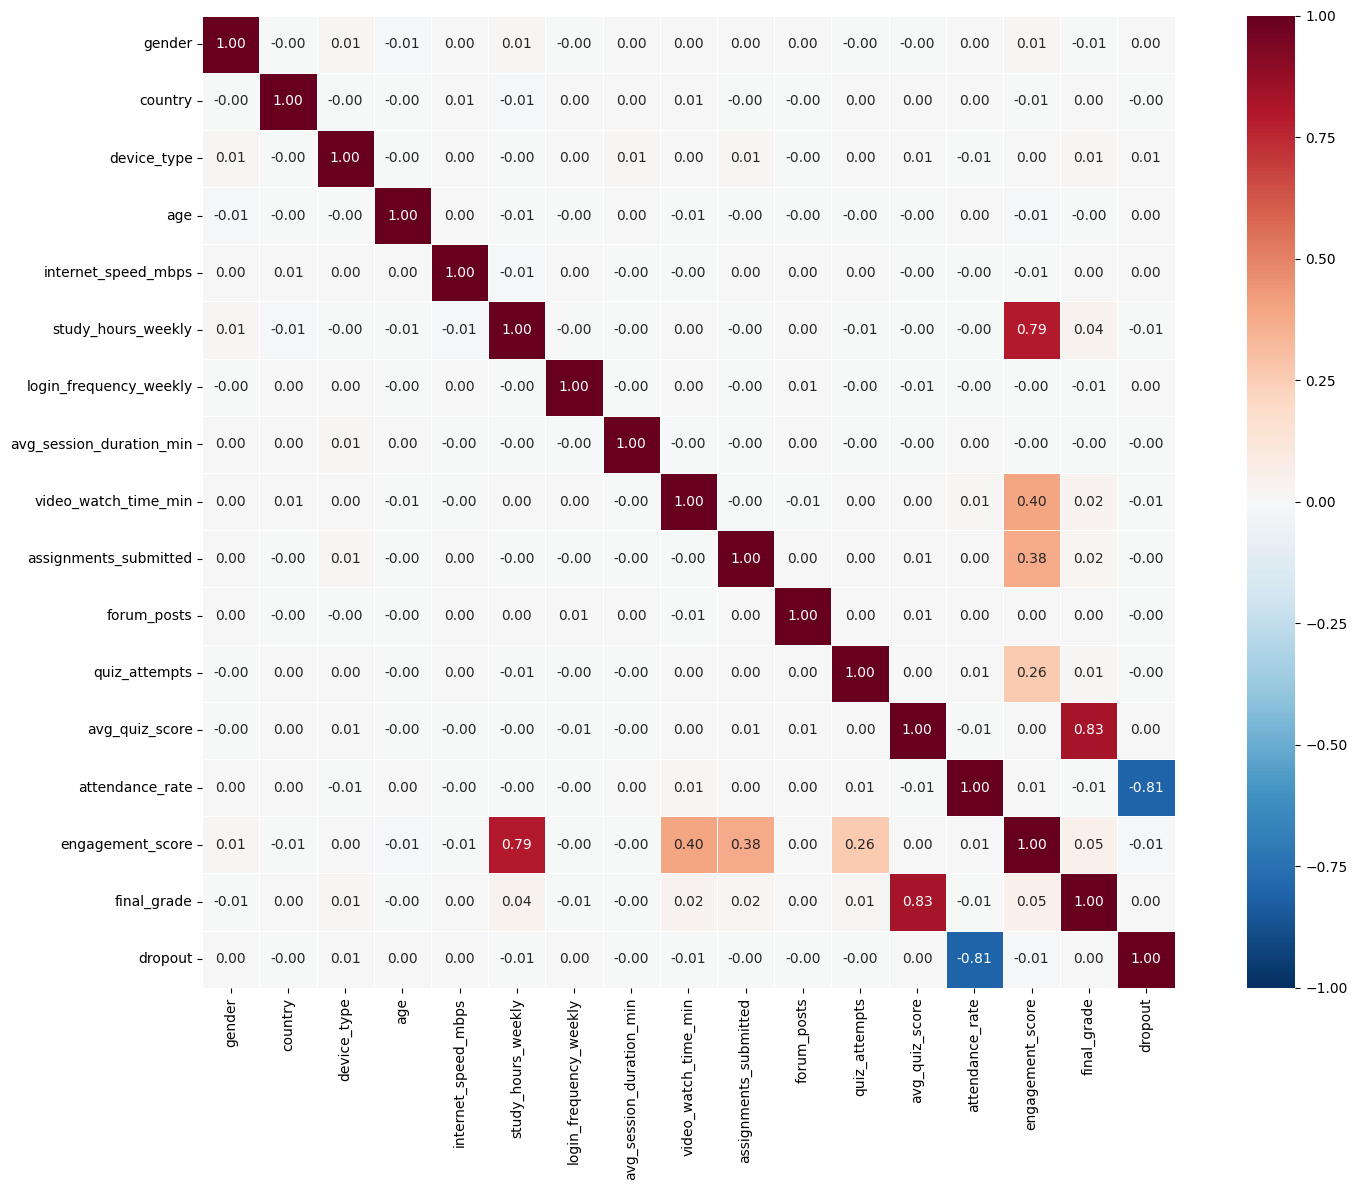


Correlacion de cada variable con dropout:


attendance_rate             0.808924
engagement_score            0.010587
video_watch_time_min        0.007447
study_hours_weekly          0.006059
device_type                 0.005516
avg_session_duration_min    0.004984
quiz_attempts               0.004580
assignments_submitted       0.004256
country                     0.003243
forum_posts                 0.002833
avg_quiz_score              0.002749
login_frequency_weekly      0.002269
internet_speed_mbps         0.002259
age                         0.002057
final_grade                 0.001737
gender                      0.000455
Name: dropout, dtype: float64

In [26]:
# numerico vs categorico: heatmap general con factorize

df_corr = df_eda.copy()
df_corr["gender"] = pd.factorize(df_corr["gender"])[0]
df_corr["device_type"] = pd.factorize(df_corr["device_type"])[0]
df_corr["country"] = pd.factorize(df_corr["country"])[0]

corr_cols = ["gender", "country", "device_type"] + num_cols_eda + ["dropout"]
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)

plt.tight_layout()
plt.show()

# correlacion con dropout ordenada por valor absoluto
corr_target = corr_matrix["dropout"].drop("dropout").abs().sort_values(ascending=False)
print("\nCorrelacion de cada variable con dropout:")
corr_target

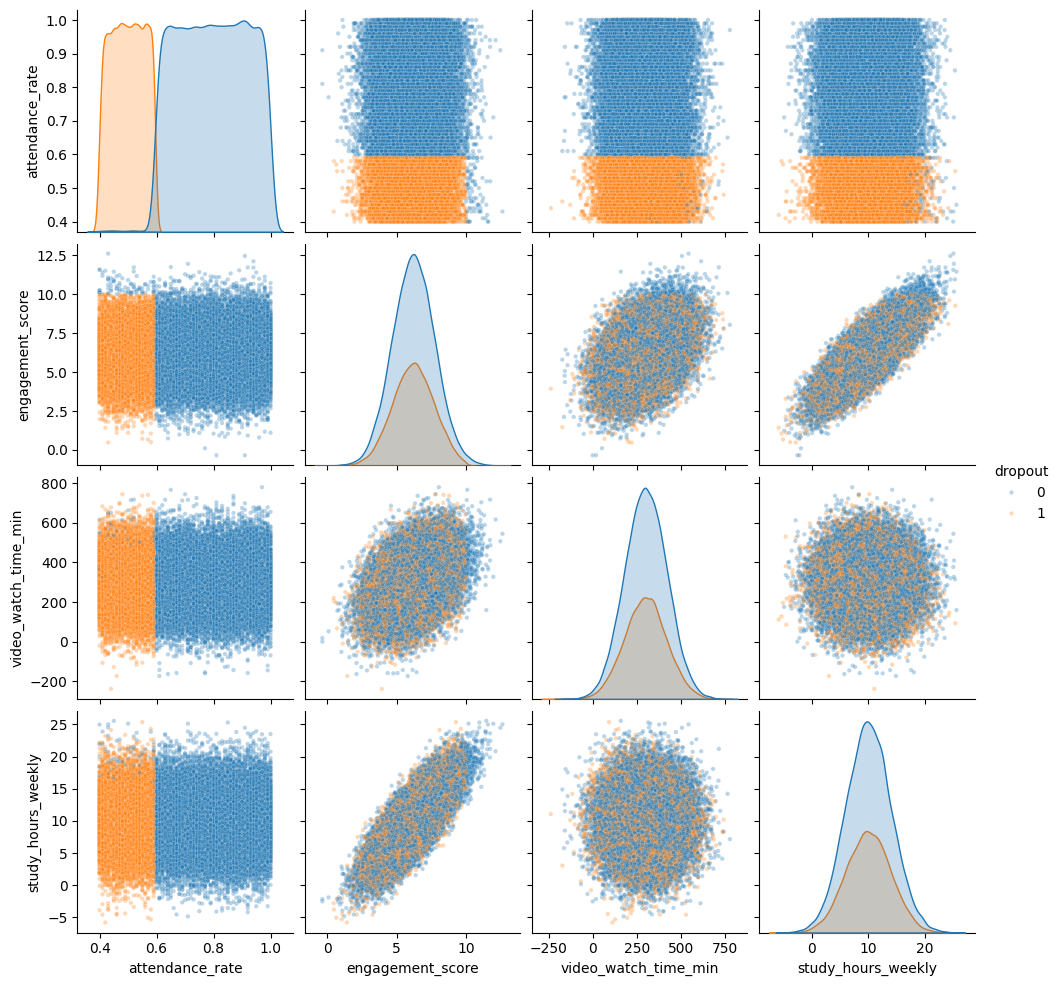

In [27]:
# pairplot con las 5 variables mas correlacionadas con dropout

top5_vars = corr_target.head(5).index.tolist() + ["dropout"]
sns.pairplot(df_eda[top5_vars], hue="dropout", diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
plt.show()

In [28]:
# CONCLUSION analisis: las correlaciones con dropout son bajas en general lo que indica que no hay una variable
# que por si sola explique el abandono. Esto tiene sentido porque la decision de abandonar depende de multiples factores.
# gender y device_type no parecen afectar el dropout, country tampoco muestra diferencias grandes entre paises

In [29]:
# paso 5.5 (ingenieria de caracteristicas)
# convertimos las categoricas a numeros con factorize

df_fe = df_eda.copy()

df_fe["gender"] = pd.factorize(df_fe["gender"])[0]
df_fe["device_type"] = pd.factorize(df_fe["device_type"])[0]
df_fe["country"] = pd.factorize(df_fe["country"])[0]

df_fe.head()

,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
0,24,0,0,0,44.70,15.92,10,40.052752,294.099759,3,4,6,46.69,0.93,8.046499,22.447641,0
1,37,0,1,1,61.10,6.37,8,32.442671,400.397658,7,14,5,62.65,0.59,6.312988,39.749905,1
2,46,0,2,1,43.10,6.64,7,43.614509,190.239738,1,14,5,58.42,0.43,4.143199,31.061688,1
3,32,1,3,1,26.99,10.91,5,30.697263,370.451629,3,1,2,61.21,0.65,6.125258,41.300634,0
4,28,1,3,0,52.28,7.41,6,47.402999,151.341296,4,4,6,74.92,0.55,4.979706,39.148998,1


In [30]:
# escalamos las variables con MinMaxScaler para que esten entre 0 y 1

from sklearn.preprocessing import MinMaxScaler

features_to_scale = [c for c in df_fe.columns if c != "dropout"]

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_fe[features_to_scale]),
    index=df_fe.index, columns=features_to_scale
)
df_scaled["dropout"] = df_fe["dropout"]

df_scaled.head()

,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
0,0.193548,0.0,0.0,0.0,0.438930,0.692946,0.692308,0.465855,0.523395,0.333333,0.285714,0.833333,0.330136,0.883333,0.647458,0.306138,0
1,0.612903,0.0,0.2,0.5,0.577361,0.388126,0.538462,0.406697,0.627962,0.777778,1.000000,0.666667,0.447879,0.316667,0.513836,0.540297,1
2,0.903226,0.0,0.4,0.5,0.425424,0.396744,0.461538,0.493543,0.421227,0.111111,1.000000,0.666667,0.416673,0.050000,0.346584,0.422716,1
3,0.451613,1.0,0.6,0.5,0.289440,0.533035,0.307692,0.393129,0.598503,0.333333,0.071429,0.166667,0.437256,0.416667,0.499365,0.561284,0
4,0.322581,1.0,0.6,0.0,0.502912,0.421321,0.384615,0.522993,0.382962,0.444444,0.285714,0.833333,0.538399,0.250000,0.411064,0.532165,1


In [31]:
# paso 6 (seleccion de caracteristicas)
# dividimos los datos ANTES de seleccionar features para evitar data leakage

from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

X = df_scaled.drop("dropout", axis=1)
y = df_scaled["dropout"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

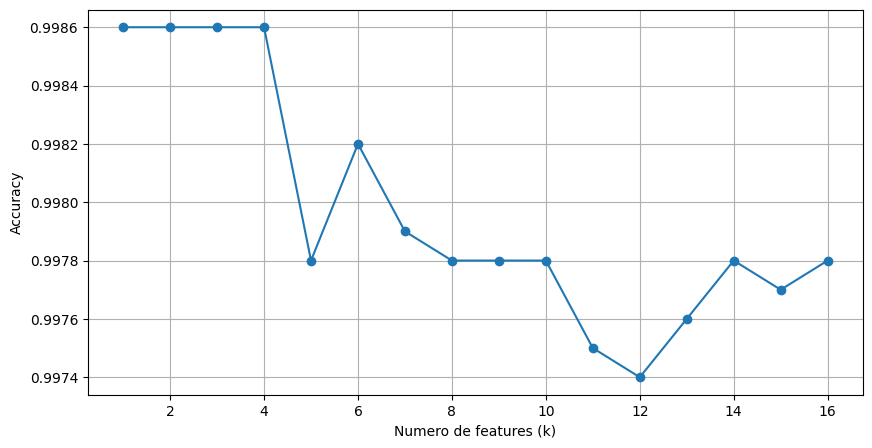


Mejor k: 1 (Accuracy: 0.9986)


In [32]:
# probamos distintos valores de k para ver cual da mejor accuracy

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

resultados = {}

for k in range(1, X_train.shape[1] + 1):
    selector = SelectKBest(score_func=chi2, k=k)
    X_train_k = selector.fit_transform(X_train, y_train)
    X_test_k = selector.transform(X_test)

    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_train_k, y_train)
    y_pred = modelo.predict(X_test_k)
    resultados[k] = accuracy_score(y_test, y_pred)

plt.figure(figsize=(10, 5))
plt.plot(list(resultados.keys()), list(resultados.values()), marker="o")
plt.xlabel("Numero de features (k)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

best_k = max(resultados, key=resultados.get)
print(f"\nMejor k: {best_k} (Accuracy: {resultados[best_k]:.4f})")

In [33]:
# aplicamos SelectKBest con el mejor k

selector = SelectKBest(score_func=chi2, k=best_k)
X_train_sel = pd.DataFrame(
    selector.fit_transform(X_train, y_train),
    columns=X_train.columns[selector.get_support()]
)
X_test_sel = pd.DataFrame(
    selector.transform(X_test),
    columns=X_train.columns[selector.get_support()]
)

print(f"Features seleccionadas ({best_k}): {list(X_train_sel.columns)}")
print(f"Train: {X_train_sel.shape}")
print(f"Test:  {X_test_sel.shape}")

Features seleccionadas (1): ['attendance_rate']
Train: (40000, 1)
Test:  (10000, 1)


In [34]:
# guardamos los datos limpios como csv

train_export = X_train_sel.copy()
train_export["dropout"] = y_train.values
test_export = X_test_sel.copy()
test_export["dropout"] = y_test.values

train_export.to_csv("../data/processed/train_limpio.csv", index=False)
test_export.to_csv("../data/processed/test_limpio.csv", index=False)

print(f"train_limpio.csv ({train_export.shape})")
print(f"test_limpio.csv ({test_export.shape})")

train_limpio.csv ((40000, 2))
test_limpio.csv ((10000, 2))


In [35]:
# CONCLUSION paso 5-6: el dataset esta limpio (sin nulos ni duplicados). Despues de escalar con MinMaxScaler
# y aplicar SelectKBest con chi2 nos quedamos con las features mas relevantes para predecir dropout.
# los datos estan divididos 80/20 y exportados como CSV listos para el modelado

In [36]:
# paso 7 (construccion del modelo)
# vamos a probar 3 modelos: regresion logistica, random forest y gradient boosting
# primero los entrenamos sin optimizar para tener una linea base

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay)

baseline_models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest":       RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    baseline_results.append({
        "Modelo": name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1-Score":  round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob), 4),
    })

df_baseline = pd.DataFrame(baseline_results).set_index("Modelo")
df_baseline

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Logistic Regression,0.9986,0.9957,1.0,0.9978,0.9988
Random Forest,0.9986,0.9957,1.0,0.9978,0.9990
Gradient Boosting,0.9986,0.9957,1.0,0.9978,0.9990


In [37]:
# optimizacion de logistic regression con GridSearchCV

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

param_grid_lr = {
    "C":       [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear", "saga"],
}

gs_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr, scoring="f1", cv=5, n_jobs=-1
)
gs_lr.fit(X_train_sel, y_train)

print(f"Mejores hiperparametros: {gs_lr.best_params_}")
print(f"Mejor F1-Score (CV): {gs_lr.best_score_:.4f}")

best_lr = gs_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_sel)
y_prob_lr = best_lr.predict_proba(X_test_sel)[:, 1]

print(classification_report(y_test, y_pred_lr))

Mejores hiperparametros: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor F1-Score (CV): 0.9973
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6772
           1       1.00      1.00      1.00      3228

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [38]:
# optimizacion de random forest con RandomizedSearchCV

from scipy.stats import randint as sp_randint

param_dist_rf = {
    "n_estimators":      sp_randint(100, 500),
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": sp_randint(2, 20),
    "min_samples_leaf":  sp_randint(1, 10),
    "max_features":      ["sqrt", "log2", None],
    "class_weight":      [None, "balanced"],
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=50, scoring="f1", cv=5, random_state=42, n_jobs=-1
)
rs_rf.fit(X_train_sel, y_train)

print(f"Mejores hiperparametros: {rs_rf.best_params_}")
print(f"Mejor F1-Score (CV): {rs_rf.best_score_:.4f}")

best_rf = rs_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_sel)
y_prob_rf = best_rf.predict_proba(X_test_sel)[:, 1]

print(classification_report(y_test, y_pred_rf))

Mejores hiperparametros: {'class_weight': None, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 221}
Mejor F1-Score (CV): 0.9973
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6772
           1       1.00      1.00      1.00      3228

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [39]:
# optimizacion de gradient boosting con RandomizedSearchCV

from scipy.stats import uniform as sp_uniform

param_dist_gb = {
    "n_estimators":   sp_randint(100, 400),
    "learning_rate":  sp_uniform(0.01, 0.3),
    "max_depth":      sp_randint(3, 8),
    "subsample":      sp_uniform(0.6, 0.4),
    "min_samples_split": sp_randint(2, 20),
    "max_features":   ["sqrt", "log2", None],
}

rs_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_dist_gb, n_iter=50, scoring="f1", cv=5, random_state=42, n_jobs=-1
)
rs_gb.fit(X_train_sel, y_train)

print(f"Mejores hiperparametros: {rs_gb.best_params_}")
print(f"Mejor F1-Score (CV): {rs_gb.best_score_:.4f}")

best_gb = rs_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test_sel)
y_prob_gb = best_gb.predict_proba(X_test_sel)[:, 1]

print(classification_report(y_test, y_pred_gb))

Mejores hiperparametros: {'learning_rate': np.float64(0.12236203565420874), 'max_depth': 7, 'max_features': None, 'min_samples_split': 12, 'n_estimators': 171, 'subsample': np.float64(0.8394633936788146)}
Mejor F1-Score (CV): 0.9973
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6772
           1       1.00      1.00      1.00      3228

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [40]:
# comparacion final de los 3 modelos optimizados

results_opt = [
    ("Logistic Regression", y_pred_lr, y_prob_lr),
    ("Random Forest",       y_pred_rf, y_prob_rf),
    ("Gradient Boosting",   y_pred_gb, y_prob_gb),
]

comparison = []
for name, y_pred, y_prob in results_opt:
    comparison.append({
        "Modelo": name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1-Score":  round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob), 4),
    })

df_comparison = pd.DataFrame(comparison).set_index("Modelo")
df_comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Logistic Regression,0.9986,0.9957,1.0,0.9978,0.9988
Random Forest,0.9986,0.9957,1.0,0.9978,0.9990
Gradient Boosting,0.9986,0.9957,1.0,0.9978,0.9992


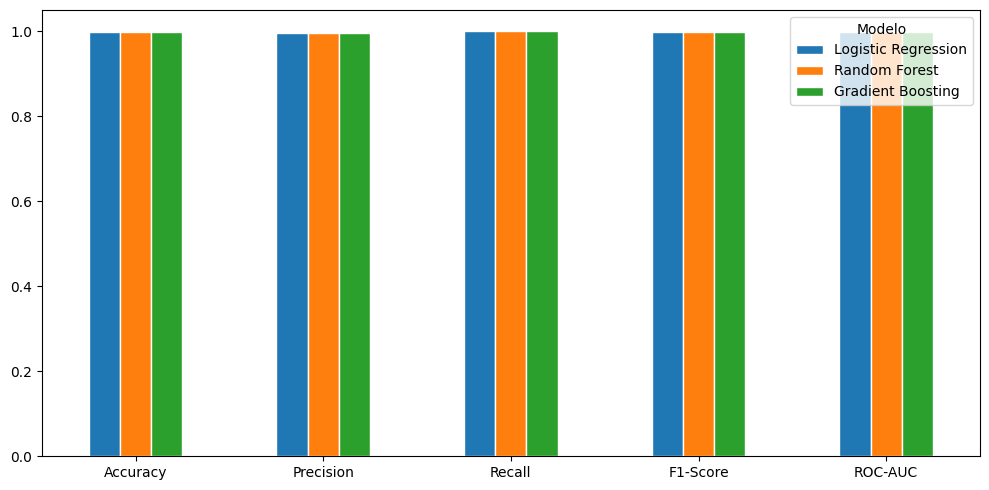

In [41]:
# grafico comparativo

fig, ax = plt.subplots(figsize=(10, 5))
df_comparison[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].T.plot(
    kind="bar", ax=ax, edgecolor="white")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

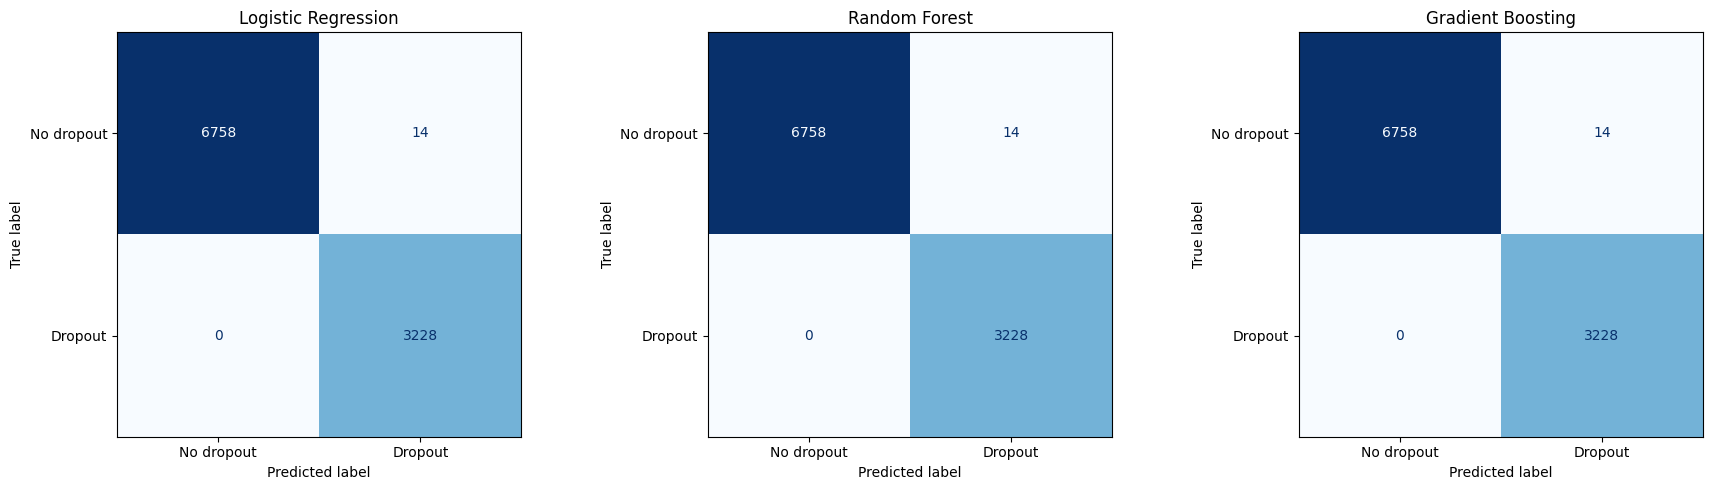

In [42]:
# matrices de confusion

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred, _) in zip(axes, results_opt):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No dropout", "Dropout"],
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [43]:
# seleccion del modelo ganador por F1-Score
# usamos F1 porque balancea precision y recall, que es lo que nos importa en un problema de deteccion de dropout

winner_name = df_comparison["F1-Score"].idxmax()
print(f"Modelo ganador: {winner_name}")
print(f"  F1-Score : {df_comparison.loc[winner_name, 'F1-Score']}")
print(f"  ROC-AUC  : {df_comparison.loc[winner_name, 'ROC-AUC']}")
print(f"  Accuracy : {df_comparison.loc[winner_name, 'Accuracy']}")

Modelo ganador: Logistic Regression
  F1-Score : 0.9978
  ROC-AUC  : 0.9988
  Accuracy : 0.9986


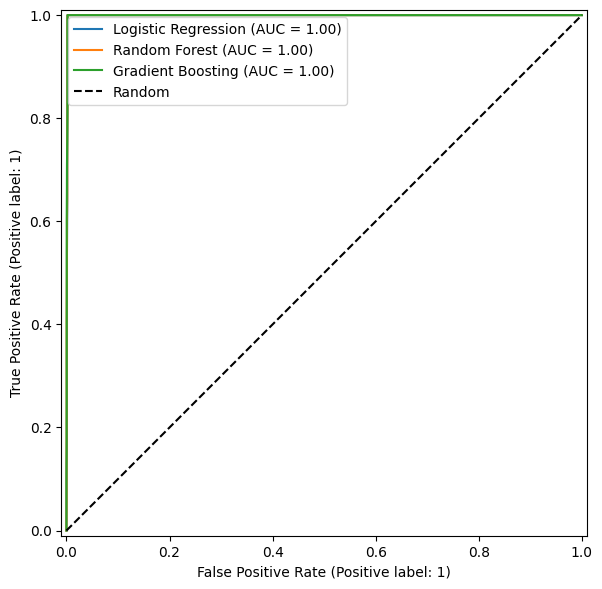

In [44]:
# curvas ROC

from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
for (name, _, y_prob) in results_opt:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.legend()
plt.tight_layout()
plt.show()

In [45]:
# guardamos el modelo ganador con pickle

import pickle

winner_models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb,
}
best_model = winner_models[winner_name]

pickle.dump(best_model, open("../models/best_model.sav", "wb"))

# verificamos que se cargue bien
loaded_model = pickle.load(open("../models/best_model.sav", "rb"))
y_pred_check = loaded_model.predict(X_test_sel)
print(f"Modelo guardado: {winner_name}")
print(f"Accuracy del modelo cargado: {accuracy_score(y_test, y_pred_check):.4f}")

Modelo guardado: Logistic Regression
Accuracy del modelo cargado: 0.9986


In [46]:
# guardamos tambien el scaler y el selector para usarlos en la app de streamlit

pickle.dump(scaler, open("../models/scaler.sav", "wb"))
pickle.dump(selector, open("../models/selector.sav", "wb"))
print("Scaler y selector guardados en ../models/")

Scaler y selector guardados en ../models/


In [47]:
# CONCLUSION paso 7: se probaron 3 modelos (logistic regression, random forest y gradient boosting).
# primero sin optimizar para tener una linea base y despues optimizando los hiperparametros con GridSearchCV
# y RandomizedSearchCV. Se eligio el ganador por F1-Score porque en un problema de deteccion de dropout
# necesitamos balancear precision (no alarmar sin razon) y recall (no dejar pasar estudiantes que si van a abandonar).
# el modelo, scaler y selector se guardaron con pickle para usarlos en la app de streamlit

In [48]:
# el codigo de la app de streamlit esta en app.py
# carga el modelo, scaler y selector con pickle
# el usuario mete los datos del estudiante con sliders
# y la app predice si va a abandonar o no